# Day 10: Non-Linear Models & Overfitting

## Task: The Depth Test.

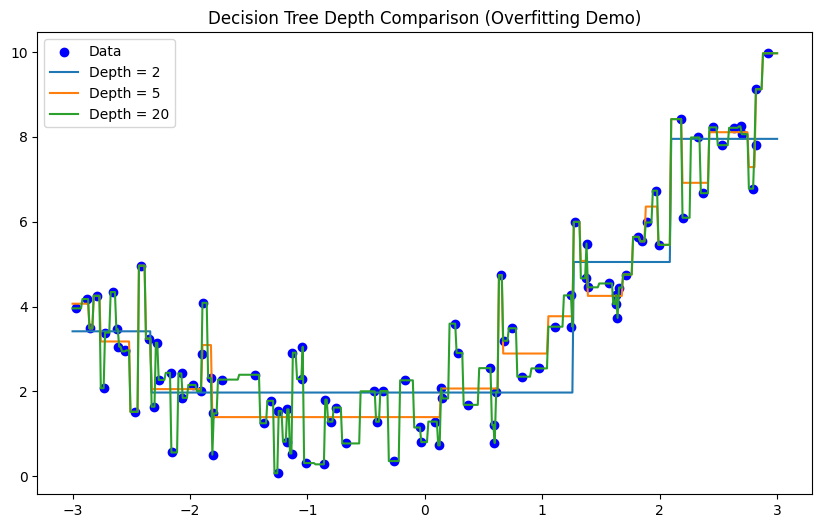

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Generate data (same as before)
np.random.seed(42)
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

# Create smooth X for plotting
X_new = np.linspace(-3, 3, 500).reshape(-1, 1)

# Different depths
depths = [2, 5, 20]

plt.figure(figsize=(10,6))
plt.scatter(X, y, color='blue', label='Data')

# Train and plot each tree
for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth)
    tree.fit(X, y)
    y_pred = tree.predict(X_new)
    plt.plot(X_new, y_pred, label=f"Depth = {depth}")

plt.legend()
plt.title("Decision Tree Depth Comparison (Overfitting Demo)")
plt.show()

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Make sure X and y are already defined above this cell

# Polynomial
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

print("R² Scores:")

# Polynomial R²
poly_r2 = r2_score(y, poly_model.predict(X_poly))
print(f"Polynomial: {poly_r2:.3f}")

# Decision Tree
depths = [2, 5, 20]

for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth)
    tree.fit(X, y)
    tree_r2 = r2_score(y, tree.predict(X))
    print(f"Tree depth={depth}: {tree_r2:.3f}")

R² Scores:
Polynomial: 0.853
Tree depth=2: 0.813
Tree depth=5: 0.929
Tree depth=20: 1.000


#### Reflect:
#### Why is a 'jittery' model that hits every training point actually worse for making future predictions than a smooth 'curvy' model?

#### Answer: 
#### A jittery model that hits every training point is worse because it memorizes the noise instead of learning the actual pattern in the data. This leads to overfitting, where the model performs very well on training data but poorly on new, unseen data. A smooth curvy model captures the general trend, making it more reliable and better for future predictions.